# Librerias

In [9]:
import os
import pandas as pd

from dotenv import load_dotenv
from sqlalchemy import create_engine, text, URL


load_dotenv()

url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT", 5432)),
    database=os.getenv("DB_NAME")
)

engine = create_engine(url)

df = pd.read_sql(
    text("""
        SELECT *
        FROM dataset_modelo
        ORDER BY periodo, comuna
    """),
    engine
)


In [14]:
df

,comuna,periodo,temperatura,humedad,viento,vegetacion_cobertura,incendios_historicos,ocurrencia_incendio,codigo_estacion,nombre_estacion,distancia_estacion_km,anio_cobertura
0,Algarrobo,2010-09-01,14.993958,68.235650,9.160121,Bosques,0,0,330007,"Rodelillo, Ad.",29.57,2001
1,Cartagena,2010-09-01,12.902051,74.864103,6.076923,Bosques,0,0,330030,"Santo Domingo, Ad.",20.92,2001
2,Casablanca,2010-09-01,14.993958,68.235650,9.160121,Bosques,0,0,330007,"Rodelillo, Ad.",30.01,2001
3,El Quisco,2010-09-01,12.902051,74.864103,6.076923,Bosques,0,0,330030,"Santo Domingo, Ad.",26.96,2001
4,El Tabo,2010-09-01,12.902051,74.864103,6.076923,Bosques,0,0,330030,"Santo Domingo, Ad.",19.49,2001
...,...,...,...,...,...,...,...,...,...,...,...,...
4508,Santo Domingo,2025-05-01,11.618011,87.131720,4.139382,Bosques,27,0,330030,"Santo Domingo, Ad.",18.01,2023
4509,Valparaíso,2025-05-01,13.455511,78.311559,3.536290,Bosques,45,1,330007,"Rodelillo, Ad.",7.30,2023
4510,Villa Alemana,2025-05-01,12.954032,80.796774,4.227151,Bosques,13,0,320041,Viña del Mar Ad. (Torquemada),18.90,2023
4511,Viña del Mar,2025-05-01,13.455511,78.311559,3.536290,Áreas Urbanas e Industriales,10,0,330007,"Rodelillo, Ad.",5.68,2023


# Data Understanding

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4513 entries, 0 to 4512
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   comuna                 4513 non-null   object 
 1   periodo                4513 non-null   object 
 2   temperatura            4513 non-null   float64
 3   humedad                4513 non-null   float64
 4   viento                 4513 non-null   float64
 5   vegetacion_cobertura   4513 non-null   object 
 6   incendios_historicos   4513 non-null   int64  
 7   ocurrencia_incendio    4513 non-null   int64  
 8   codigo_estacion        4513 non-null   object 
 9   nombre_estacion        4513 non-null   object 
 10  distancia_estacion_km  4513 non-null   float64
 11  anio_cobertura         4513 non-null   int64  
dtypes: float64(4), int64(3), object(5)
memory usage: 423.2+ KB


In [16]:
print("Registros:", len(df))
print("Comunas:", df["comuna"].nunique())
print("Periodo:", df["periodo"].min(), "a", df["periodo"].max())

print("\nNulos:")
print(df.isna().sum())

print("\nDistribución target:")
print(df["ocurrencia_incendio"].value_counts())
print(df["ocurrencia_incendio"].value_counts(normalize=True).round(3))

Registros: 4513
Comunas: 36
Periodo: 2010-09-01 a 2025-05-01

Nulos:
comuna                   0
periodo                  0
temperatura              0
humedad                  0
viento                   0
vegetacion_cobertura     0
incendios_historicos     0
ocurrencia_incendio      0
codigo_estacion          0
nombre_estacion          0
distancia_estacion_km    0
anio_cobertura           0
dtype: int64

Distribución target:
ocurrencia_incendio
0    2483
1    2030
Name: count, dtype: int64
ocurrencia_incendio
0    0.55
1    0.45
Name: proportion, dtype: float64


In [17]:
df["periodo"] = pd.to_datetime(df["periodo"])

df = df.sort_values(
    ["periodo", "comuna"]
).reset_index(drop=True)

df.head()

,comuna,periodo,temperatura,humedad,viento,vegetacion_cobertura,incendios_historicos,ocurrencia_incendio,codigo_estacion,nombre_estacion,distancia_estacion_km,anio_cobertura
0,Algarrobo,2010-09-01,14.993958,68.235650,9.160121,Bosques,0,0,330007,"Rodelillo, Ad.",29.57,2001
1,Cartagena,2010-09-01,12.902051,74.864103,6.076923,Bosques,0,0,330030,"Santo Domingo, Ad.",20.92,2001
2,Casablanca,2010-09-01,14.993958,68.235650,9.160121,Bosques,0,0,330007,"Rodelillo, Ad.",30.01,2001
3,El Quisco,2010-09-01,12.902051,74.864103,6.076923,Bosques,0,0,330030,"Santo Domingo, Ad.",26.96,2001
4,El Tabo,2010-09-01,12.902051,74.864103,6.076923,Bosques,0,0,330030,"Santo Domingo, Ad.",19.49,2001


In [19]:
(
    df["vegetacion_cobertura"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

vegetacion_cobertura
Bosques                             81.56
Terrenos Agrícolas                   7.82
Praderas y Matorrales                4.72
Áreas Desprovistas de Vegetación     4.72
Áreas Urbanas e Industriales         1.17
Name: proportion, dtype: float64

In [20]:
df["ocurrencia_incendio"].value_counts()

ocurrencia_incendio
0    2483
1    2030
Name: count, dtype: int64

In [21]:
(
    df["ocurrencia_incendio"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

ocurrencia_incendio
0    55.02
1    44.98
Name: proportion, dtype: float64

In [22]:
columnas_correlacion = [
    "temperatura",
    "humedad",
    "viento",
    "incendios_historicos",
    "ocurrencia_incendio"
]

correlacion = df[columnas_correlacion].corr()

correlacion.round(3)

,temperatura,humedad,viento,incendios_historicos,ocurrencia_incendio
temperatura,1.000,-0.557,0.108,-0.031,0.374
humedad,-0.557,1.000,0.364,0.128,-0.022
viento,0.108,0.364,1.000,0.269,0.317
incendios_historicos,-0.031,0.128,0.269,1.000,0.235
ocurrencia_incendio,0.374,-0.022,0.317,0.235,1.000


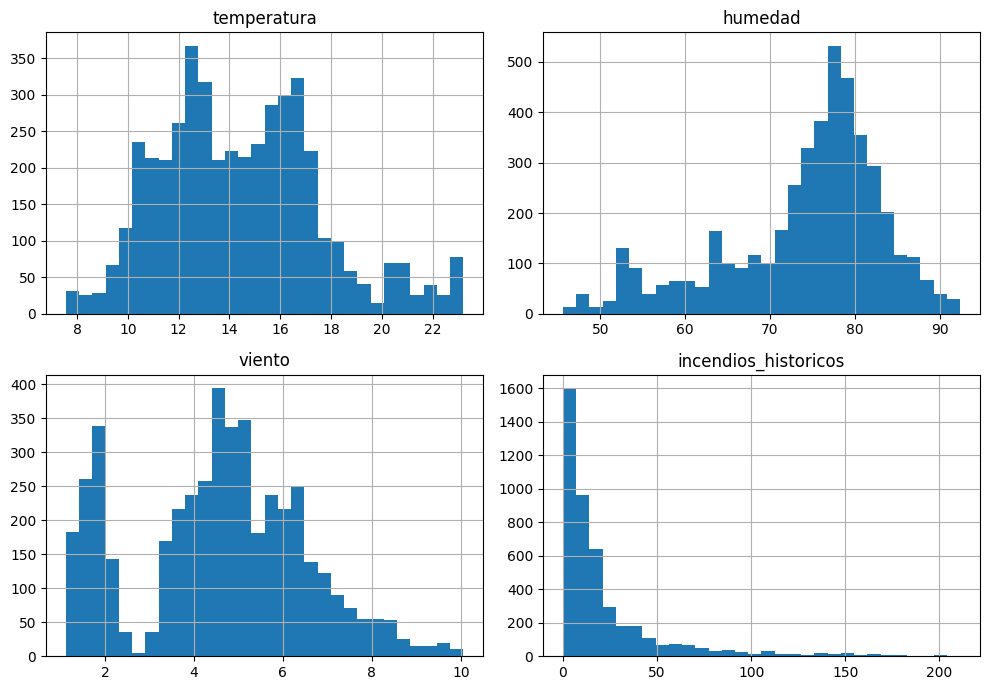

In [24]:
import matplotlib.pyplot as plt

df[numericas].hist(figsize=(10, 7), bins=30)
plt.tight_layout()
plt.show()

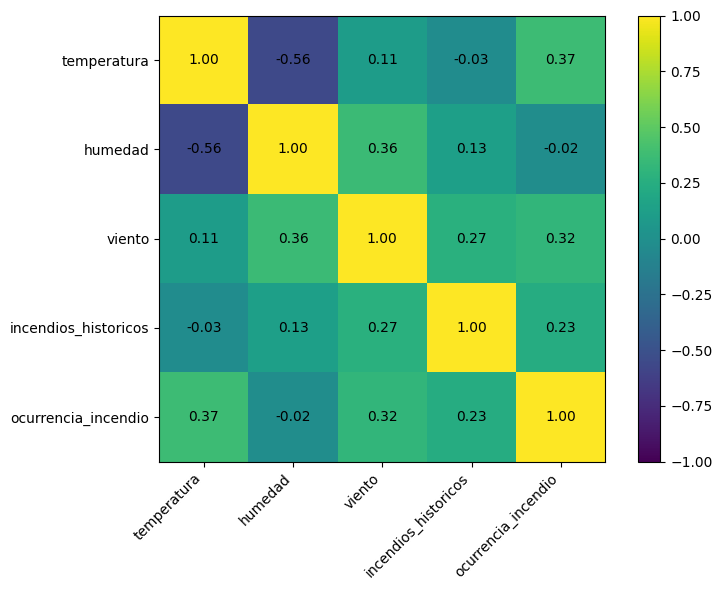

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))

imagen = ax.imshow(correlacion, vmin=-1, vmax=1)

ax.set_xticks(range(len(correlacion.columns)))
ax.set_yticks(range(len(correlacion.columns)))

ax.set_xticklabels(correlacion.columns, rotation=45, ha="right")
ax.set_yticklabels(correlacion.columns)

for i in range(len(correlacion.columns)):
    for j in range(len(correlacion.columns)):
        ax.text(
            j,
            i,
            f"{correlacion.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(imagen)
plt.tight_layout()
plt.show()

In [26]:
df[columnas_correlacion].corr(method="spearman").round(3)

,temperatura,humedad,viento,incendios_historicos,ocurrencia_incendio
temperatura,1.000,-0.449,0.270,-0.027,0.440
humedad,-0.449,1.000,0.155,0.221,-0.076
viento,0.270,0.155,1.000,0.364,0.333
incendios_historicos,-0.027,0.221,0.364,1.000,0.315
ocurrencia_incendio,0.440,-0.076,0.333,0.315,1.000


In [27]:
df.groupby("ocurrencia_incendio")[numericas].agg(
    ["mean", "median"]
).round(2)

temperatura        humedad        viento         \
                           mean median    mean median   mean median   
ocurrencia_incendio                                                   
0                         13.39  12.63   74.29  77.40   4.03   4.27   
1                         15.77  15.84   73.88  75.54   5.25   5.30   

                    incendios_historicos         
                                    mean median  
ocurrencia_incendio                              
0                                  16.22    8.0  
1                                  31.05   17.0

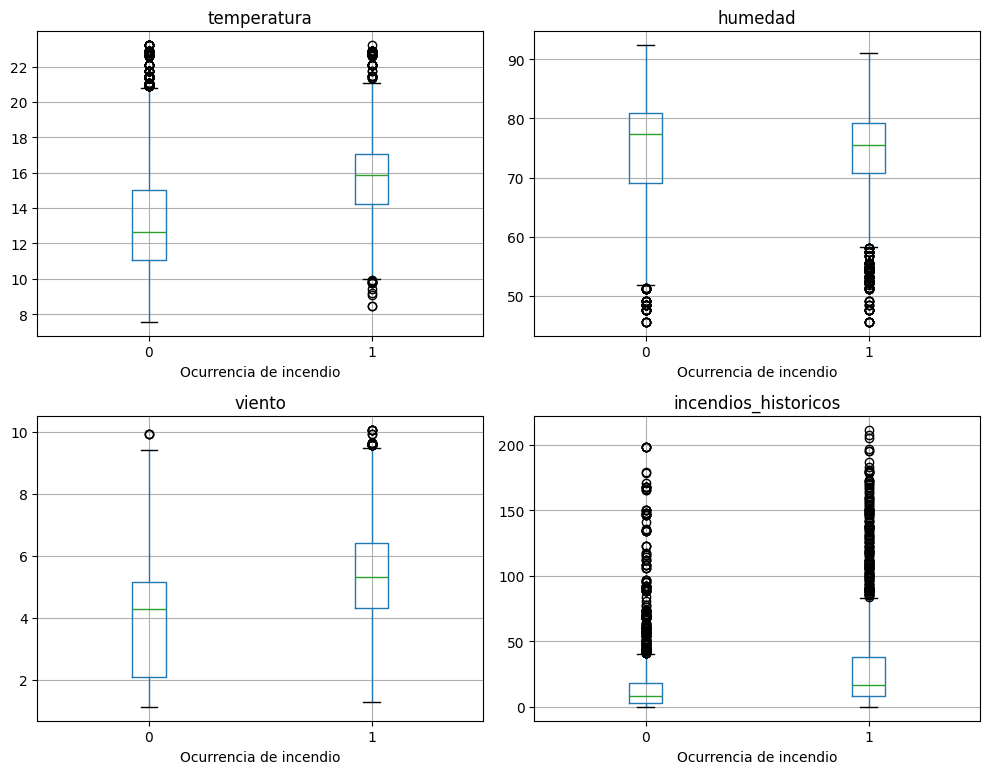

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for variable, ax in zip(numericas, axes.flatten()):
    df.boxplot(
        column=variable,
        by="ocurrencia_incendio",
        ax=ax
    )
    ax.set_title(variable)
    ax.set_xlabel("Ocurrencia de incendio")

plt.suptitle("")
plt.tight_layout()
plt.show()

In [29]:
tabla_vegetacion = pd.crosstab(
    df["vegetacion_cobertura"],
    df["ocurrencia_incendio"]
)

tabla_vegetacion

ocurrencia_incendio,0,1
vegetacion_cobertura,,
Bosques,1868,1813
Praderas y Matorrales,181,32
Terrenos Agrícolas,238,115
Áreas Desprovistas de Vegetación,170,43
Áreas Urbanas e Industriales,26,27


In [30]:
df["periodo"] = pd.to_datetime(df["periodo"])
df["mes"] = df["periodo"].dt.month

In [31]:
incendios_por_mes = (
    df.groupby("mes")["ocurrencia_incendio"]
    .mean()
    .mul(100)
    .round(2)
)

incendios_por_mes

mes
1     75.52
2     70.05
3     63.02
4     52.34
5     35.68
6     11.49
7      5.54
8     10.53
9     17.52
10    39.32
11    70.83
12    79.43
Name: ocurrencia_incendio, dtype: float64

In [32]:
resumen_mes = (
    df.groupby("mes")["ocurrencia_incendio"]
    .agg(["count", "sum", "mean"])
)

resumen_mes["porcentaje_incendio"] = (
    resumen_mes["mean"] * 100
).round(2)

resumen_mes

,count,sum,mean,porcentaje_incendio
mes,,,,
1,384,290,0.755208,75.52
2,384,269,0.700521,70.05
3,384,242,0.630208,63.02
4,384,201,0.523438,52.34
5,384,137,0.356771,35.68
6,348,40,0.114943,11.49
7,361,20,0.055402,5.54
8,361,38,0.105263,10.53
9,371,65,0.175202,17.52


In [33]:
from scipy.stats import chi2_contingency

tabla = pd.crosstab(
    df["vegetacion_cobertura"],
    df["ocurrencia_incendio"]
)

chi2, p, dof, expected = chi2_contingency(tabla)

print("Chi-cuadrado:", round(chi2, 2))
print("p-value:", p)

Chi-cuadrado: 179.99
p-value: 7.475161376922176e-38


In [34]:
import numpy as np

n = tabla.to_numpy().sum()

cramers_v = np.sqrt(
    chi2 / (n * min(tabla.shape[0] - 1, tabla.shape[1] - 1))
)

print("V de Cramér:", round(cramers_v, 3))

V de Cramér: 0.2


# Data Preparation

In [35]:
df_modelo = df.copy()

df_modelo["periodo"] = pd.to_datetime(df_modelo["periodo"])
df_modelo = df_modelo.sort_values(
    ["periodo", "comuna"]
).reset_index(drop=True)

In [36]:
print("Duplicados:", df_modelo.duplicated(
    subset=["comuna", "periodo"]
).sum())

print("\nNulos:")
print(df_modelo.isna().sum())

print("\nTarget:")
print(df_modelo["ocurrencia_incendio"].value_counts())

Duplicados: 0

Nulos:
comuna                   0
periodo                  0
temperatura              0
humedad                  0
viento                   0
vegetacion_cobertura     0
incendios_historicos     0
ocurrencia_incendio      0
codigo_estacion          0
nombre_estacion          0
distancia_estacion_km    0
anio_cobertura           0
mes                      0
dtype: int64

Target:
ocurrencia_incendio
0    2483
1    2030
Name: count, dtype: int64


In [37]:
variables_numericas = [
    "temperatura",
    "humedad",
    "viento",
    "incendios_historicos"
]

variable_categorica = [
    "vegetacion_cobertura"
]

target = "ocurrencia_incendio"

In [38]:
periodos = (
    df_modelo["periodo"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

len(periodos)

177

In [39]:
n = len(periodos)

corte_train = int(n * 0.70)
corte_validacion = int(n * 0.85)

fin_train = periodos.iloc[corte_train - 1]
fin_validacion = periodos.iloc[corte_validacion - 1]

print("Train hasta:", fin_train)
print("Validación hasta:", fin_validacion)
print("Test desde:", periodos.iloc[corte_validacion])

Train hasta: 2020-11-01 00:00:00
Validación hasta: 2023-02-01 00:00:00
Test desde: 2023-03-01 00:00:00


In [ ]:
train = df_modelo[df_modelo["periodo"] <= fin_train].copy()

validacion = df_modelo[(df_modelo["periodo"] > fin_train)& (df_modelo["periodo"] <= fin_validacion)].copy()

test = df_modelo[df_modelo["periodo"] > fin_validacion].copy()

In [47]:
for nombre, datos in [
    ("TRAIN", train),
    ("VALIDACIÓN", validacion),
    ("TEST", test)
]:
    print(f"\n{nombre}")
    print("Registros:", len(datos))
    print(
        "Periodo:",
        datos["periodo"].min().date(),
        "a",
        datos["periodo"].max().date()
    )

    print("\nDistribución target:")
    print(datos["ocurrencia_incendio"].value_counts())

    print("\nPorcentaje:")
    print(
        datos["ocurrencia_incendio"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )


TRAIN
Registros: 2569
Periodo: 2010-09-01 a 2020-11-01

Distribución target:
ocurrencia_incendio
1    1305
0    1264
Name: count, dtype: int64

Porcentaje:
ocurrencia_incendio
1    50.8
0    49.2
Name: proportion, dtype: float64

VALIDACIÓN
Registros: 972
Periodo: 2020-12-01 a 2023-02-01

Distribución target:
ocurrencia_incendio
0    607
1    365
Name: count, dtype: int64

Porcentaje:
ocurrencia_incendio
0    62.45
1    37.55
Name: proportion, dtype: float64

TEST
Registros: 972
Periodo: 2023-03-01 a 2025-05-01

Distribución target:
ocurrencia_incendio
0    612
1    360
Name: count, dtype: int64

Porcentaje:
ocurrencia_incendio
0    62.96
1    37.04
Name: proportion, dtype: float64


In [50]:
variables = [
    "temperatura",
    "humedad",
    "viento",
    "vegetacion_cobertura",
    "incendios_historicos"
]

target = "ocurrencia_incendio"

X_train = train[variables]
y_train = train[target]

X_val = validacion[variables]
y_val = validacion[target]

X_test = test[variables]
y_test = test[target]

In [52]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (2569, 5)
X_val: (972, 5)
X_test: (972, 5)


In [71]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocesador = ColumnTransformer(
    transformers=[
        (
            "vegetacion",
            OneHotEncoder(handle_unknown="ignore"),
            variable_categorica
        )
    ],
    remainder="passthrough"
)

# Entrenamiento

In [72]:
import numpy as np

periodos_train = (
    train["periodo"]
    .drop_duplicates()
    .sort_values()
    .to_numpy()
)

bloques = np.array_split(periodos_train, 5)

cv_temporal = []

for i in range(1, len(bloques)):
    periodos_entrenamiento = np.concatenate(bloques[:i])
    periodos_validacion = bloques[i]

    indices_train = np.where(
        train["periodo"].isin(periodos_entrenamiento)
    )[0]

    indices_val = np.where(
        train["periodo"].isin(periodos_validacion)
    )[0]

    cv_temporal.append(
        (indices_train, indices_val)
    )

print("Folds temporales:", len(cv_temporal))

Folds temporales: 4


In [73]:
for i, (idx_train, idx_val) in enumerate(cv_temporal, 1):
    print(f"\nFold {i}")
    print(
        "Train:",
        train.iloc[idx_train]["periodo"].min().date(),
        "→",
        train.iloc[idx_train]["periodo"].max().date()
    )
    print(
        "Validación:",
        train.iloc[idx_val]["periodo"].min().date(),
        "→",
        train.iloc[idx_val]["periodo"].max().date()
    )


Fold 1
Train: 2010-09-01 → 2012-09-01
Validación: 2012-10-01 → 2014-10-01

Fold 2
Train: 2010-09-01 → 2014-10-01
Validación: 2014-11-01 → 2016-11-01

Fold 3
Train: 2010-09-01 → 2016-11-01
Validación: 2016-12-01 → 2018-11-01

Fold 4
Train: 2010-09-01 → 2018-11-01
Validación: 2018-12-01 → 2020-11-01


# MODELOS E HIPERPARAMETROS

In [74]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


modelos = {
    "Random Forest": {
        "pipeline": Pipeline([
            ("preprocesamiento", clone(preprocesador)),
            ("modelo", RandomForestClassifier(
                random_state=42,
                n_jobs=1
            ))
        ]),
        "parametros": {
            "modelo__n_estimators": [200, 400],
            "modelo__max_depth": [None, 8, 15],
            "modelo__min_samples_split": [2, 5],
            "modelo__min_samples_leaf": [1, 3]
        }
    },

    "XGBoost": {
        "pipeline": Pipeline([
            ("preprocesamiento", clone(preprocesador)),
            ("modelo", XGBClassifier(
                random_state=42,
                eval_metric="logloss",
                n_jobs=1
            ))
        ]),
        "parametros": {
            "modelo__n_estimators": [200, 400],
            "modelo__max_depth": [3, 5, 7],
            "modelo__learning_rate": [0.03, 0.1],
            "modelo__subsample": [0.8, 1.0]
        }
    },

    "LightGBM": {
        "pipeline": Pipeline([
            ("preprocesamiento", clone(preprocesador)),
            ("modelo", LGBMClassifier(
                random_state=42,
                verbosity=-1,
                n_jobs=1
            ))
        ]),
        "parametros": {
            "modelo__n_estimators": [200, 400],
            "modelo__num_leaves": [15, 31, 63],
            "modelo__learning_rate": [0.03, 0.1],
            "modelo__min_child_samples": [10, 20]
        }
    }
}

# GRIDSEARCH

In [ ]:
from sklearn.model_selection import GridSearchCV
import time


metricas_grid = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

busquedas = {}


for nombre, configuracion in modelos.items():

    print(f"\nEntrenando {nombre}...")

    grid = GridSearchCV(
        estimator=configuracion["pipeline"],
        param_grid=configuracion["parametros"],
        scoring=metricas_grid,
        refit="f1",
        cv=cv_temporal,
        n_jobs=-1,
        return_train_score=True
    )

    inicio = time.perf_counter()

    grid.fit(X_train, y_train)

    duracion = time.perf_counter() - inicio

    busquedas[nombre] = {
        "grid": grid,
        "duracion": duracion
    }

    print("Mejor F1 CV:", round(grid.best_score_, 3))
    print("Mejores parámetros:", grid.best_params_)
    print("Tiempo:", round(duracion, 2), "segundos")

# METRICAS TRAIN VS VALIDATION


In [76]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


def evaluar_modelo(modelo, X, y):

    predicciones = modelo.predict(X)
    probabilidades = modelo.predict_proba(X)[:, 1]

    return {
        "Accuracy": accuracy_score(y, predicciones),
        "Precision": precision_score(y, predicciones),
        "Recall": recall_score(y, predicciones),
        "F1": f1_score(y, predicciones),
        "ROC-AUC": roc_auc_score(y, probabilidades)
    }

In [77]:
resultados = []


for nombre, resultado in busquedas.items():

    modelo = resultado["grid"].best_estimator_

    train_metricas = evaluar_modelo(
        modelo,
        X_train,
        y_train
    )

    val_metricas = evaluar_modelo(
        modelo,
        X_val,
        y_val
    )

    resultados.append({
        "Modelo": nombre,

        "Accuracy Train": train_metricas["Accuracy"],
        "Accuracy Val": val_metricas["Accuracy"],

        "Precision Train": train_metricas["Precision"],
        "Precision Val": val_metricas["Precision"],

        "Recall Train": train_metricas["Recall"],
        "Recall Val": val_metricas["Recall"],

        "F1 Train": train_metricas["F1"],
        "F1 Val": val_metricas["F1"],

        "ROC-AUC Train": train_metricas["ROC-AUC"],
        "ROC-AUC Val": val_metricas["ROC-AUC"],

        "Tiempo (s)": resultado["duracion"]
    })

In [78]:
comparacion_modelos = pd.DataFrame(resultados)

comparacion_modelos["Brecha Accuracy"] = (
    comparacion_modelos["Accuracy Train"]
    - comparacion_modelos["Accuracy Val"]
)

comparacion_modelos["Brecha F1"] = (
    comparacion_modelos["F1 Train"]
    - comparacion_modelos["F1 Val"]
)

comparacion_modelos["Brecha ROC-AUC"] = (
    comparacion_modelos["ROC-AUC Train"]
    - comparacion_modelos["ROC-AUC Val"]
)

comparacion_modelos.round(3)

,Modelo,Accuracy Train,Accuracy Val,Precision Train,Precision Val,Recall Train,Recall Val,F1 Train,F1 Val,ROC-AUC Train,ROC-AUC Val,Tiempo (s),Brecha Accuracy,Brecha F1,Brecha ROC-AUC
0,Random Forest,0.838,0.731,0.842,0.659,0.840,0.592,0.841,0.623,0.924,0.797,6.909,0.107,0.217,0.127
1,XGBoost,0.808,0.743,0.812,0.678,0.811,0.600,0.811,0.637,0.895,0.803,1.923,0.066,0.175,0.092
2,LightGBM,0.835,0.725,0.840,0.655,0.835,0.567,0.837,0.608,0.927,0.796,1.517,0.110,0.230,0.132


## Comportamiento temporal Train vs Validación

In [79]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score

resultados_folds = []

for nombre, resultado in busquedas.items():

    mejor_modelo = resultado["grid"].best_estimator_

    for numero_fold, (idx_train, idx_val) in enumerate(cv_temporal, 1):

        modelo_fold = clone(mejor_modelo)

        X_tr = X_train.iloc[idx_train]
        y_tr = y_train.iloc[idx_train]

        X_v = X_train.iloc[idx_val]
        y_v = y_train.iloc[idx_val]

        modelo_fold.fit(X_tr, y_tr)

        pred_train = modelo_fold.predict(X_tr)
        pred_val = modelo_fold.predict(X_v)

        resultados_folds.append({
            "Modelo": nombre,
            "Fold": numero_fold,
            "Registros Train": len(X_tr),
            "Accuracy Train": accuracy_score(y_tr, pred_train),
            "Accuracy Validación": accuracy_score(y_v, pred_val)
        })

df_folds = pd.DataFrame(resultados_folds)

df_folds.round(3)

,Modelo,Fold,Registros Train,Accuracy Train,Accuracy Validación
0,Random Forest,1,250,0.912,0.704
1,Random Forest,2,669,0.867,0.769
2,Random Forest,3,1244,0.854,0.784
3,Random Forest,4,1796,0.850,0.780
4,XGBoost,1,250,0.936,0.721
5,XGBoost,2,669,0.852,0.753
6,XGBoost,3,1244,0.823,0.781
7,XGBoost,4,1796,0.820,0.780
8,LightGBM,1,250,0.968,0.735
9,LightGBM,2,669,0.907,0.757


In [80]:
df_folds["Brecha Accuracy"] = (
    df_folds["Accuracy Train"]
    - df_folds["Accuracy Validación"]
)

df_folds.round(3)

,Modelo,Fold,Registros Train,Accuracy Train,Accuracy Validación,Brecha Accuracy
0,Random Forest,1,250,0.912,0.704,0.208
1,Random Forest,2,669,0.867,0.769,0.098
2,Random Forest,3,1244,0.854,0.784,0.069
3,Random Forest,4,1796,0.850,0.780,0.070
4,XGBoost,1,250,0.936,0.721,0.215
5,XGBoost,2,669,0.852,0.753,0.099
6,XGBoost,3,1244,0.823,0.781,0.042
7,XGBoost,4,1796,0.820,0.780,0.040
8,LightGBM,1,250,0.968,0.735,0.233
9,LightGBM,2,669,0.907,0.757,0.151


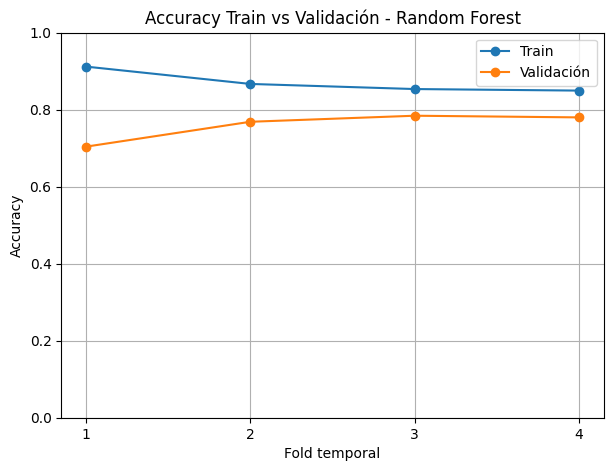

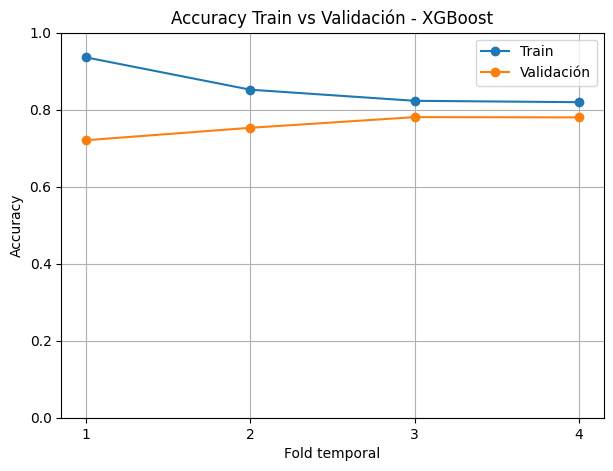

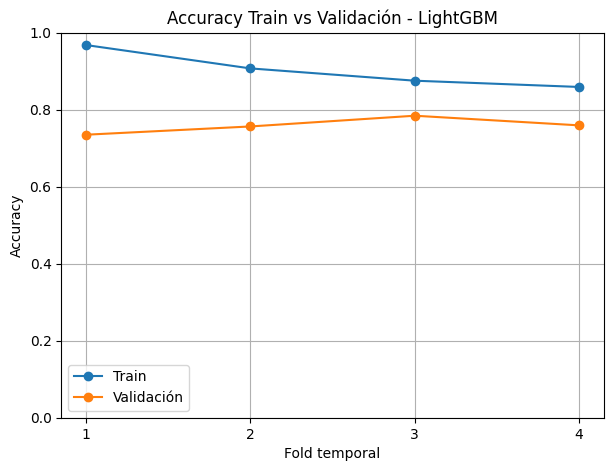

In [81]:
import matplotlib.pyplot as plt

for nombre in df_folds["Modelo"].unique():

    datos = df_folds[
        df_folds["Modelo"] == nombre
    ]

    plt.figure(figsize=(7, 5))

    plt.plot(
        datos["Fold"],
        datos["Accuracy Train"],
        marker="o",
        label="Train"
    )

    plt.plot(
        datos["Fold"],
        datos["Accuracy Validación"],
        marker="o",
        label="Validación"
    )

    plt.xlabel("Fold temporal")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy Train vs Validación - {nombre}")

    plt.xticks(datos["Fold"])
    plt.ylim(0, 1)

    plt.legend()
    plt.grid()

    plt.show()

In [83]:
resumen_folds = (
    df_folds
    .groupby("Modelo")
    .agg({
        "Accuracy Train": ["mean", "std"],
        "Accuracy Validación": ["mean", "std"],
        "Brecha Accuracy": "mean"
    })
    .round(3)
)

resumen_folds

Accuracy Train        Accuracy Validación        Brecha Accuracy
                        mean    std                mean    std            mean
Modelo                                                                        
LightGBM               0.902  0.048               0.759  0.020           0.144
Random Forest          0.871  0.029               0.759  0.037           0.111
XGBoost                0.858  0.054               0.759  0.028           0.099

# EVALUACION

## Métricas

In [88]:
metricas_evaluacion = comparacion_modelos[
    [
        "Modelo",
        "Accuracy Val",
        "Precision Val",
        "Recall Val",
        "F1 Val",
        "ROC-AUC Val"
    ]
].copy()

metricas_evaluacion.round(3)

,Modelo,Accuracy Val,Precision Val,Recall Val,F1 Val,ROC-AUC Val
0,Random Forest,0.731,0.659,0.592,0.623,0.797
1,XGBoost,0.743,0.678,0.600,0.637,0.803
2,LightGBM,0.725,0.655,0.567,0.608,0.796


## Matrices de Confusión

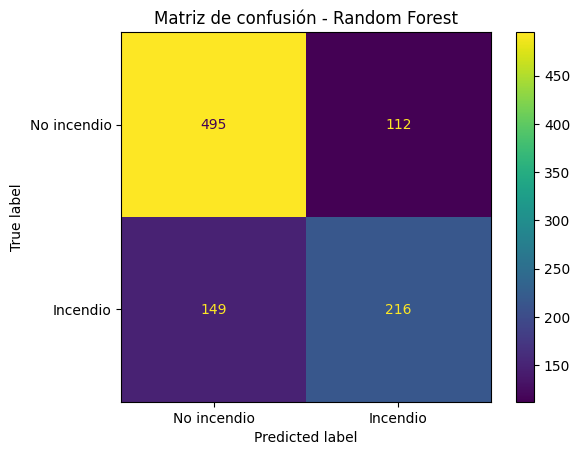

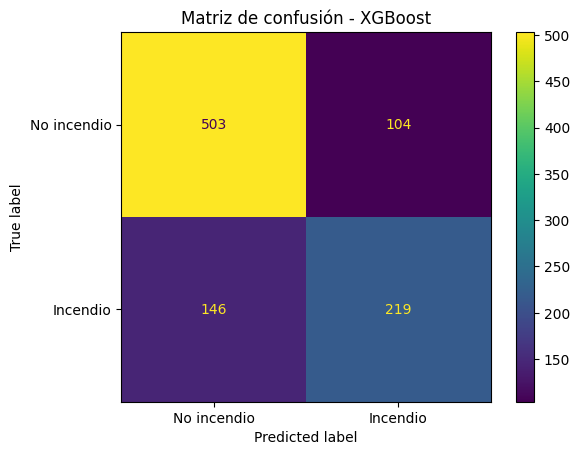

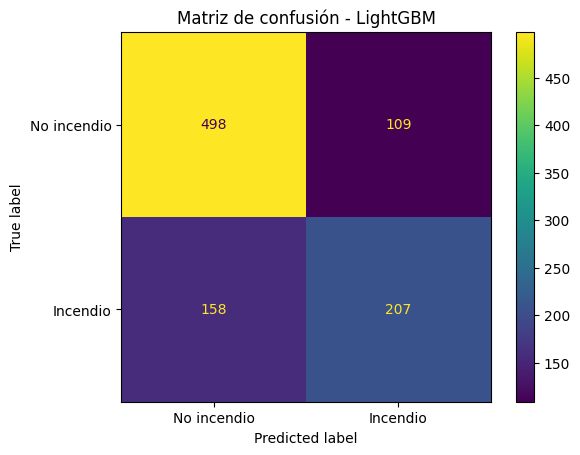

In [84]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for nombre, resultado in busquedas.items():

    modelo = resultado["grid"].best_estimator_

    y_pred = modelo.predict(X_val)

    ConfusionMatrixDisplay.from_predictions(
        y_val,
        y_pred,
        display_labels=["No incendio", "Incendio"]
    )

    plt.title(f"Matriz de confusión - {nombre}")
    plt.show()

In [85]:
resultados_confusion = []

for nombre, resultado in busquedas.items():

    modelo = resultado["grid"].best_estimator_
    y_pred = modelo.predict(X_val)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred
    ).ravel()

    resultados_confusion.append({
        "Modelo": nombre,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

pd.DataFrame(resultados_confusion)

,Modelo,TN,FP,FN,TP
0,Random Forest,495,112,149,216
1,XGBoost,503,104,146,219
2,LightGBM,498,109,158,207


## Curvas ROC

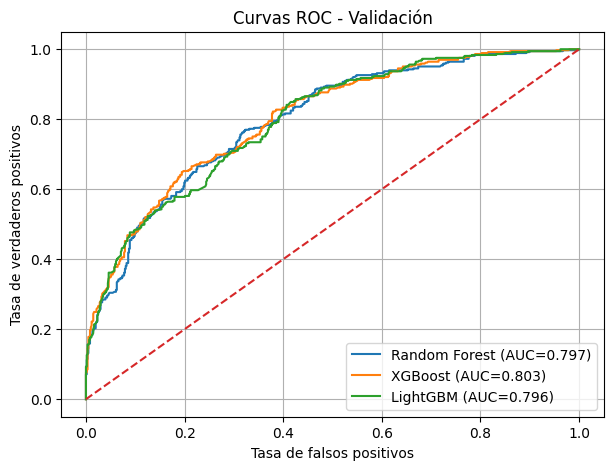

In [86]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7, 5))

for nombre, resultado in busquedas.items():

    modelo = resultado["grid"].best_estimator_

    y_prob = modelo.predict_proba(X_val)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_val,
        y_prob
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{nombre} (AUC={roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curvas ROC - Validación")
plt.legend()
plt.grid()

plt.show()

## Complemento

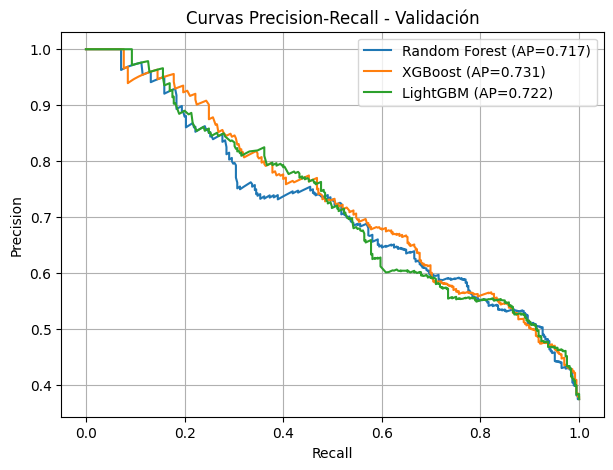

In [87]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(7, 5))

for nombre, resultado in busquedas.items():

    modelo = resultado["grid"].best_estimator_

    y_prob = modelo.predict_proba(X_val)[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_val,
        y_prob
    )

    ap = average_precision_score(
        y_val,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        label=f"{nombre} (AP={ap:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curvas Precision-Recall - Validación")
plt.legend()
plt.grid()

plt.show()

## Selección del modelo

Después de comparar Random Forest, XGBoost y LightGBM, se seleccionó
XGBoost como modelo final.

XGBoost obtuvo el mejor desempeño en el conjunto temporal de validación,
alcanzando una Accuracy de 0.743, Precision de 0.678, Recall de 0.600,
F1-score de 0.637 y ROC-AUC de 0.803.

También presentó el menor número de falsos positivos (104) y falsos
negativos (146), además de la mayor Average Precision (0.731).

Adicionalmente, mostró menores brechas entre entrenamiento y validación
que Random Forest y LightGBM, indicando una mejor capacidad de
generalización temporal.

Por estos resultados, XGBoost fue seleccionado para la evaluación final
sobre el conjunto de test.

In [90]:
modelo_seleccionado = busquedas["XGBoost"]["grid"].best_estimator_

modelo_seleccionado

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['temperatura','humedad','viento','vegetacion_cobertura', 'incendios_historicos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('vegetacion', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``

In [91]:
mejores_parametros = busquedas["XGBoost"]["grid"].best_params_

mejores_parametros

{'modelo__learning_rate': 0.03,
 'modelo__max_depth': 3,
 'modelo__n_estimators': 200,
 'modelo__subsample': 0.8}

In [92]:
{
    "modelo__learning_rate": 0.03,
    "modelo__max_depth": 3,
    "modelo__n_estimators": 200,
    "modelo__subsample": 0.8
}

{'modelo__learning_rate': 0.03,
 'modelo__max_depth': 3,
 'modelo__n_estimators': 200,
 'modelo__subsample': 0.8}

In [93]:
X_train_val = pd.concat(
    [X_train, X_val],
    ignore_index=True
)

y_train_val = pd.concat(
    [y_train, y_val],
    ignore_index=True
)

print("Train + Validación:", X_train_val.shape)
print("Test:", X_test.shape)

Train + Validación: (3541, 5)
Test: (972, 5)


In [94]:
from sklearn.base import clone

modelo_final = clone(modelo_seleccionado)

modelo_final.fit(
    X_train_val,
    y_train_val
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['temperatura','humedad','viento','vegetacion_cobertura', 'incendios_historicos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('vegetacion', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``

In [95]:
y_pred_test = modelo_final.predict(X_test)

y_prob_test = modelo_final.predict_proba(X_test)[:, 1]

In [96]:
metricas_test = {
    "Accuracy": accuracy_score(
        y_test,
        y_pred_test
    ),
    "Precision": precision_score(
        y_test,
        y_pred_test
    ),
    "Recall": recall_score(
        y_test,
        y_pred_test
    ),
    "F1": f1_score(
        y_test,
        y_pred_test
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        y_prob_test
    )
}

pd.DataFrame(
    metricas_test,
    index=["XGBoost - Test"]
).round(3)

,Accuracy,Precision,Recall,F1,ROC-AUC
XGBoost - Test,0.789,0.737,0.669,0.702,0.839


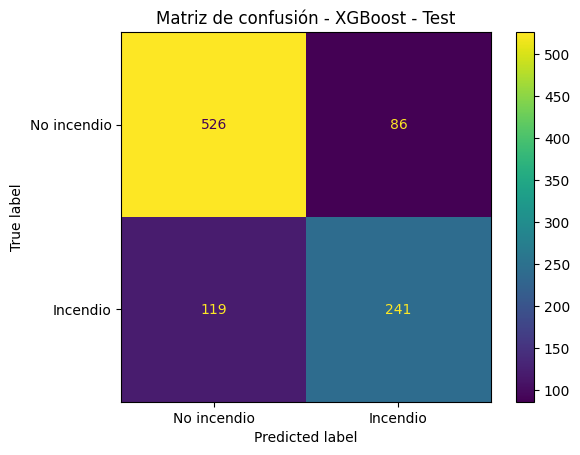

In [97]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test,
    display_labels=[
        "No incendio",
        "Incendio"
    ]
)

plt.title(
    "Matriz de confusión - XGBoost - Test"
)

plt.show()

In [98]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_test
).ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

TN: 526
FP: 86
FN: 119
TP: 241


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Azar")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC - XGBoost - Test")
plt.legend()
plt.grid(True)
plt.show()